# DSSIM Analysis

Structural dissimilarity analysis turns a video into a map of **where structure changed** between frames.

$$\mathrm{DSSIM} = \frac{1 - \mathrm{SSIM}}{2}$$

Each frame is compared with the one `FRAME_OFFSET` positions later. In the DSSIM image, dark purple regions indicate nothing changed there; bright yellow regions indicate the local structure changed. This algorithm needs no segmentation, no particle tracking, and no thresholding.

**DSSIM highlights movement as well as structural change.** Drift correcting the data is advantageous towards isolating structural change with DSSIM.

Method: [Mulvey et al., *Ultramicroscopy* **257** (2024) 113894](https://doi.org/10.1016/j.ultramic.2023.113894) · [repository](https://github.com/JustinTMulvey/DSSIM_Analysis)

---

### How to use this notebook

**I strongly recommend starting with a highly binned dataset (<1 GB) and working backward to full resolution or uncropped data.**

1. Edit only **one cell** — Section 2, *DSSIM parameters*.
2. Run all cells (`Kernel → Restart & Run All`).
3. Collect your outputs from the folder named in `OUTPUT_DIR`.

All the code and functions live in `dssim.py` next to this notebook, so the notebook itself stays minimal and usable. Every function has a docstring — `help(dssim.dssim_analysis)` at any time.

> **First time on a big dataset?** Set `MAX_FRAMES = 20` in Settings, run the whole notebook to check your parameters look right, then set it back to `None` for the real run.

## 1. Setup

Run this once. If an import fails, install the requirements with `pip install -r requirements.txt`.

In [9]:
import os
from math import ceil
import numpy as np
import matplotlib.pyplot as plt

import dssim   # the analysis module, dssim.py, sitting next to this notebook

%matplotlib inline
plt.rcParams["figure.dpi"] = 200 # increases the figure resolution
print("Ready. dssim.py loaded from", os.path.abspath(dssim.__file__))

Ready. dssim.py loaded from c:\Users\Han Solo\OneDrive - UC Irvine\Documents\SPYDER\DSSIM_Python\DSSIM_Analysis\DSSIM_Analysis_Python_Code\dssim.py


## 2. DSSIM parameters

**This is the only cell you need to edit.**

### The four that decide your result

These control what the analysis actually measures. Changing any one of them changes the DSSIM output, so these are the ones to think about and to report in a methods section. Four sounds like a lot, but their values are determined by the dataset. The Gaussian blur is related to the noise in the data, and the radius and frame offset are determined by the temporal and spatial scale of your dataset. The DSSIM exponents should generally be left alone. 

| Setting | What it does |
|---|---|
| `GAUSS_BLUR_SIGMA` | Denoising blur applied before analysis, in pixels. DSSIM reacts to *any* frame-to-frame difference, and noise contributes heavily to this — for low-dose data this parameter is what separates real structural change from counting noise. `0` disables it if preprocessing was already applied |
| `FRAME_OFFSET` | How far apart the compared frames are. `1` = consecutive, which catches the fastest changes. Larger values are more sensitive to slow events, but high values severely limit the temporal resolution (Nyquist limit) |
| `RADIUS` | Size of the comparison neighborhood, in pixels. Tune it based on the size of the feature of interest - bigger neighborhood gives smoother, higher signal maps at the cost of spatial resolution |
| `EXPONENTS` | The DSSIM coefficients [α β γ], which adjust the relative weighting of the mean, variance and cross-correlation components. Typically this is left unchanged at `(1, 1, 1)`, but `(0, 1, 1)` works better sometimes depending on the data type |

The appendix at the bottom explains how to optimize these values for a given dataset.

### Everything else

Where to read and write, and how the output looks.

| Setting | What it does |
|---|---|
| `DATA_PATH` | Your video (`.avi`/`.mp4`), a multi-page `.tif`, or a folder of `.tif` files |
| `TIMES` | Path to a one-column CSV of frame times, or `None` for 1 second per frame |
| `MAX_FRAMES` | `None` for everything, or a number to test quickly on the first N frames |
| `RUN_NAME`, `OUTPUT_DIR`, `FPS` | Naming and location of the saved files, and the video frame rate |
| `CONTRAST_TYPE` | `"constant_contrast"` to compare frames to each other, `"per_frame_contrast"` for maximum detail within each frame. Display only |
| `COLORMAP` | Color scheme for the DSSIM video. Display only |
| `OUTLIER_PCT` | Percent of extreme values clipped before display scaling. Display only |
| `REMOVE_BORDER_DIST` | Width of the blanked frame edge. The default matches how far the neighborhood reaches, so it removes exactly the pixels computed from padding rather than data |

In [10]:
# ================================================================ THE FOUR THAT MATTER THE MOST
# These decide what the analysis measures. Everything below is input, output or appearance.
GAUSS_BLUR_SIGMA = 3           # denoising blur, in pixels (0 = no blur)
FRAME_OFFSET     = 3               # compare frame n with frame n + FRAME_OFFSET
RADIUS           = 1.5             # neighborhood size, in pixels ( neighborhood = 2 * int(3 * RADIUS + 0.5) + 1))
EXPONENTS        = (1, 0, 0)       # DSSIM coefficients [a b g]: mean / variance / cross-correlation

# ---------------------------------------------------------------- input
# Use a raw string (r"...") for Windows paths so backslashes work.
DATA_PATH  = r"../example_data/LC_TEM_Tifs"

# One-column CSV of frame times, or None for 1 second per frame (easiest place to start).
TIMES      = None

# None = use every frame. Set a number to try things out quickly first.
MAX_FRAMES = None

# ---------------------------------------------------------------- output
RUN_NAME   = "run1"
OUTPUT_DIR = "dssim_output"
FPS        = 10                   # frame rate of the saved videos

# ---------------------------------------------------------------- display only
CONTRAST_TYPE = "constant_contrast"   # or "per_frame_contrast"
COLORMAP      = "viridis"
OUTLIER_PCT   = 0.1                   # % of extreme values clipped for display (removes 0.1% highs and lows)

# ---------------------------------------------------------------- rarely changed
# Blanks the frame edge, where the neighborhood would reach past the image and
# read padding instead of data. ceil(RADIUS * 3) is exactly that reach.
REMOVE_BORDER_DIST = ceil(RADIUS * 3)

# ---------------------------------------------------------------- Don't edit this
# RADIUS is the standard deviation of the Gaussian weighting, not the window size.
# The window is 2*round(3*RADIUS) + 1 px per side.
NEIGHBORHOOD = 2 * int(3 * RADIUS + 0.5) + 1
print(f"RADIUS = {RADIUS}  ->  {NEIGHBORHOOD} x {NEIGHBORHOOD} px neighborhood, "
      f"{REMOVE_BORDER_DIST} px border blanked")

RADIUS = 1.5  ->  11 x 11 px neighborhood, 5 px border blanked


## 3. Load the data

Frames are converted to single-channel float32. Color videos are averaged to greyscale.

Loading    (################################) 30/30  100%  0:00 elapsed                        
Loaded 30 frames of 512 x 512 px  (31.5 MB as float32)


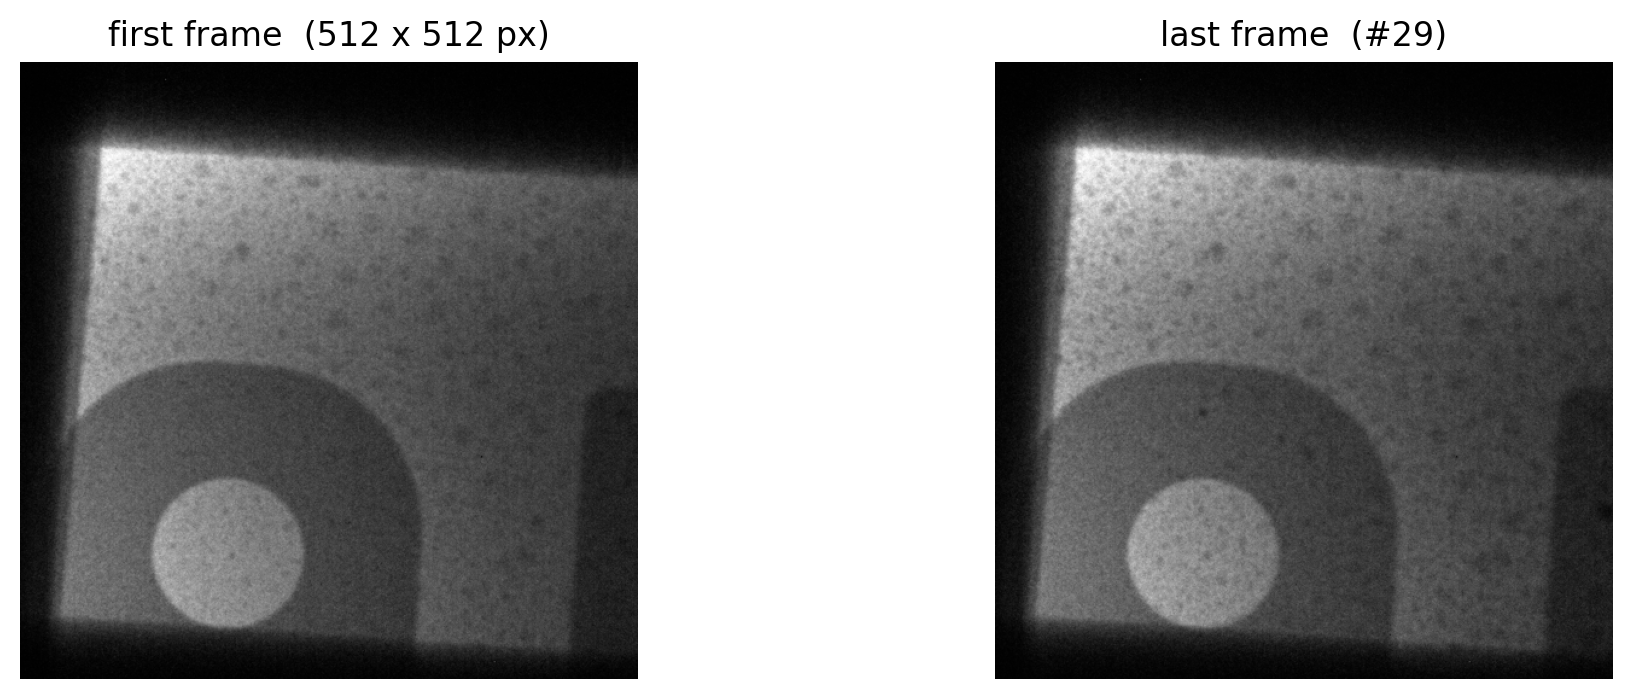

In [11]:
data = dssim.load_data(DATA_PATH, max_frames=MAX_FRAMES)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].imshow(data[0], cmap="gray")
ax[0].set_title(f"first frame  ({data.shape[2]} x {data.shape[1]} px)")
ax[1].imshow(data[-1], cmap="gray")
ax[1].set_title(f"last frame  (#{len(data) - 1})")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## 4. Run the analysis

Denoise, then compute DSSIM. A progress bar shows how far along it is and estimates the time remaining.

This is the slow step: a 1024x1024x100 frame stack takes about 20 seconds.

In [12]:
data_denoised = dssim.gaussian_denoise(data, sigma=GAUSS_BLUR_SIGMA)

result = dssim.dssim_analysis(
    data_denoised,
    times=TIMES,
    frame_offset=FRAME_OFFSET,
    radius=RADIUS,
    exponents=EXPONENTS,
    contrast_type=CONTRAST_TYPE,
    remove_border_dist=REMOVE_BORDER_DIST,
    low_pct=OUTLIER_PCT,
    high_pct=OUTLIER_PCT,
    cmap_name=COLORMAP,
    truncate_times=MAX_FRAMES is not None,   # trim the time vector to the frames loaded
)

result

Denoising  (################################) 30/30  100%  0:00 elapsed                        
No time vector given; assuming 1 second per frame.
Computing 27 DSSIM frames (offset 3, 11x11 px window)...
DSSIM      (################################) 27/27  100%  0:01 elapsed                        
Done. Mean DSSIM across the video: 0.0014


DssimResult(27 frames, 512x512 px, mean DSSIM 0.0014, window 11px)

`result` holds everything:

| Attribute | What it is |
|---|---|
| `result.dssim` | The raw DSSIM maps, `(frames, height, width)` — **this is the quantitative output** |
| `result.rgb_frames` | Colour-mapped frames for display and video export |
| `result.means` | Mean DSSIM per frame — the structural-change-over-time curve |
| `result.stats` | A pandas table of frame numbers, times and mean values |
| `result.aligned_indices` | Which original frame lines up with each DSSIM frame |

## 5. Look at the results

Raw data on top, the blurred frames that actually went into the analysis in the middle,
and the DSSIM maps below.

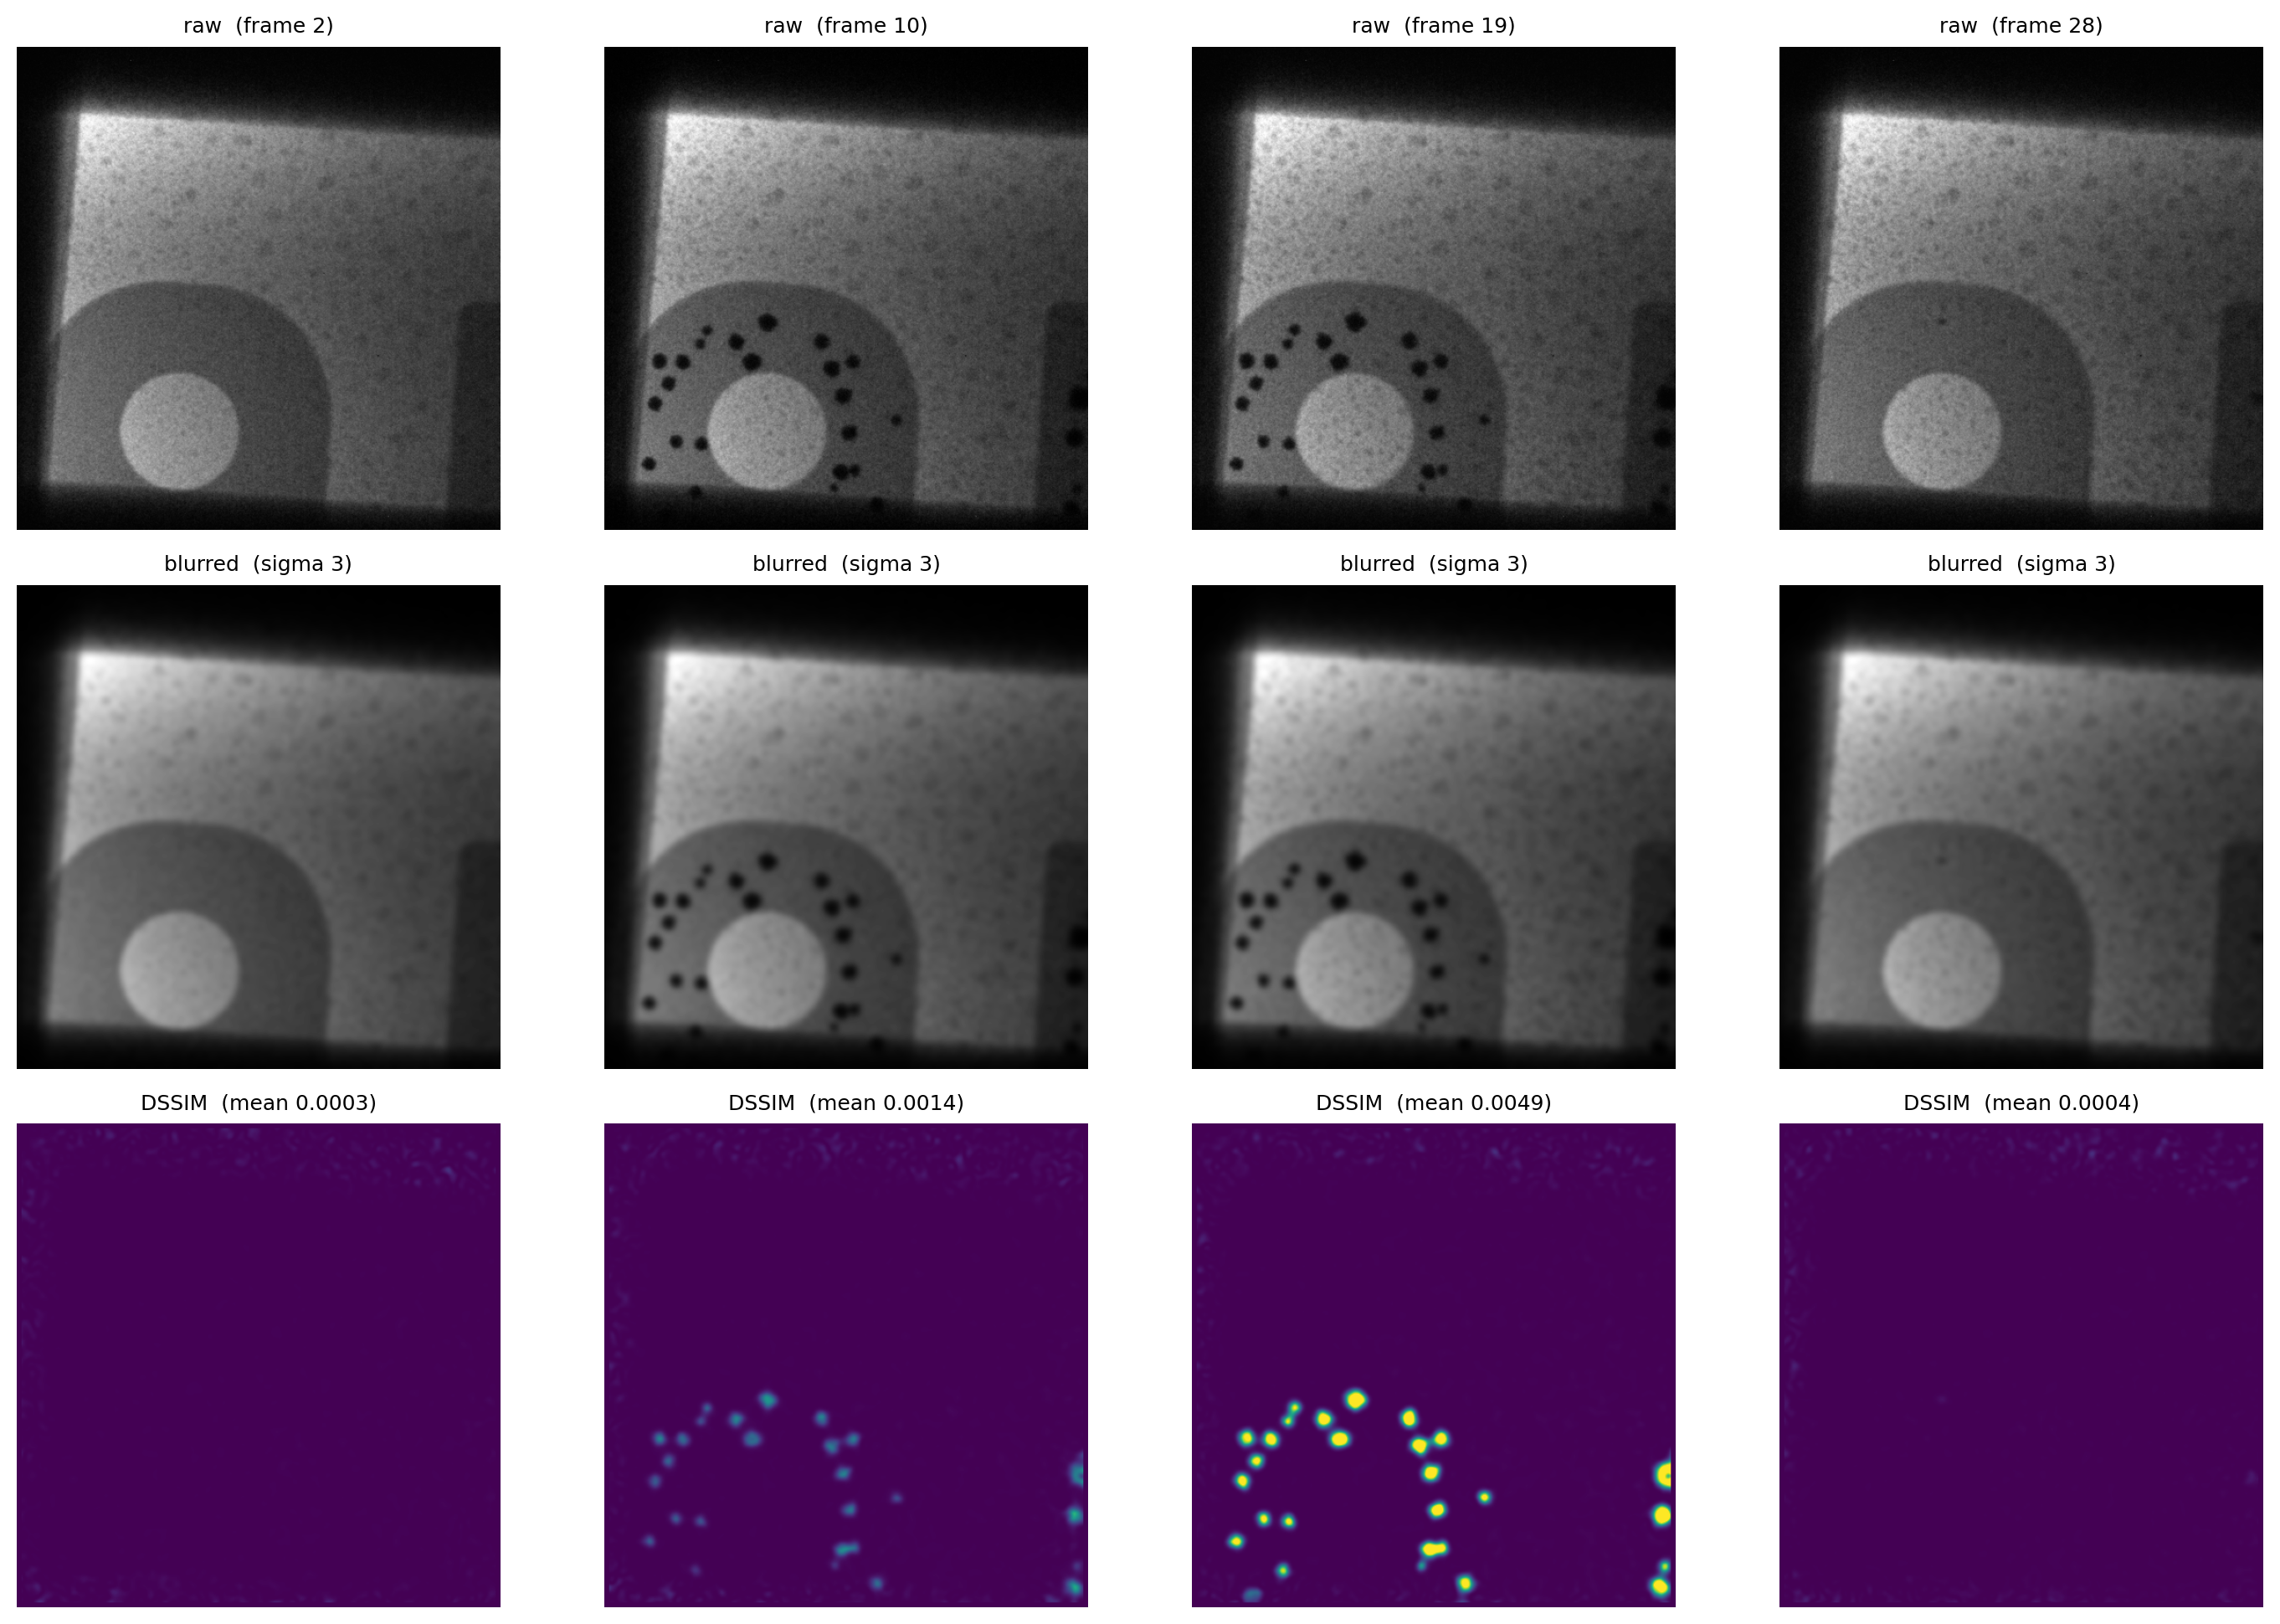

In [13]:
n_show = min(4, len(result.dssim))
picks = np.linspace(0, len(result.dssim) - 1, n_show, dtype=int)

fig, ax = plt.subplots(3, n_show, figsize=(3.6 * n_show, 9.8))
ax = np.atleast_2d(ax).reshape(3, n_show)
for col, k in enumerate(picks):
    f = result.aligned_indices[k]
    ax[0, col].imshow(data[f], cmap="gray")
    ax[0, col].set_title(f"raw  (frame {f})", fontsize=9)
    ax[1, col].imshow(data_denoised[f], cmap="gray")
    ax[1, col].set_title(f"blurred  (sigma {GAUSS_BLUR_SIGMA})", fontsize=9)
    ax[2, col].imshow(result.rgb_frames[k])
    ax[2, col].set_title(f"DSSIM  (mean {result.means[k]:.4f})", fontsize=9)
for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

### Averaged structural change over time

High values correlate to high structural change, taking an average for all parts of the image.

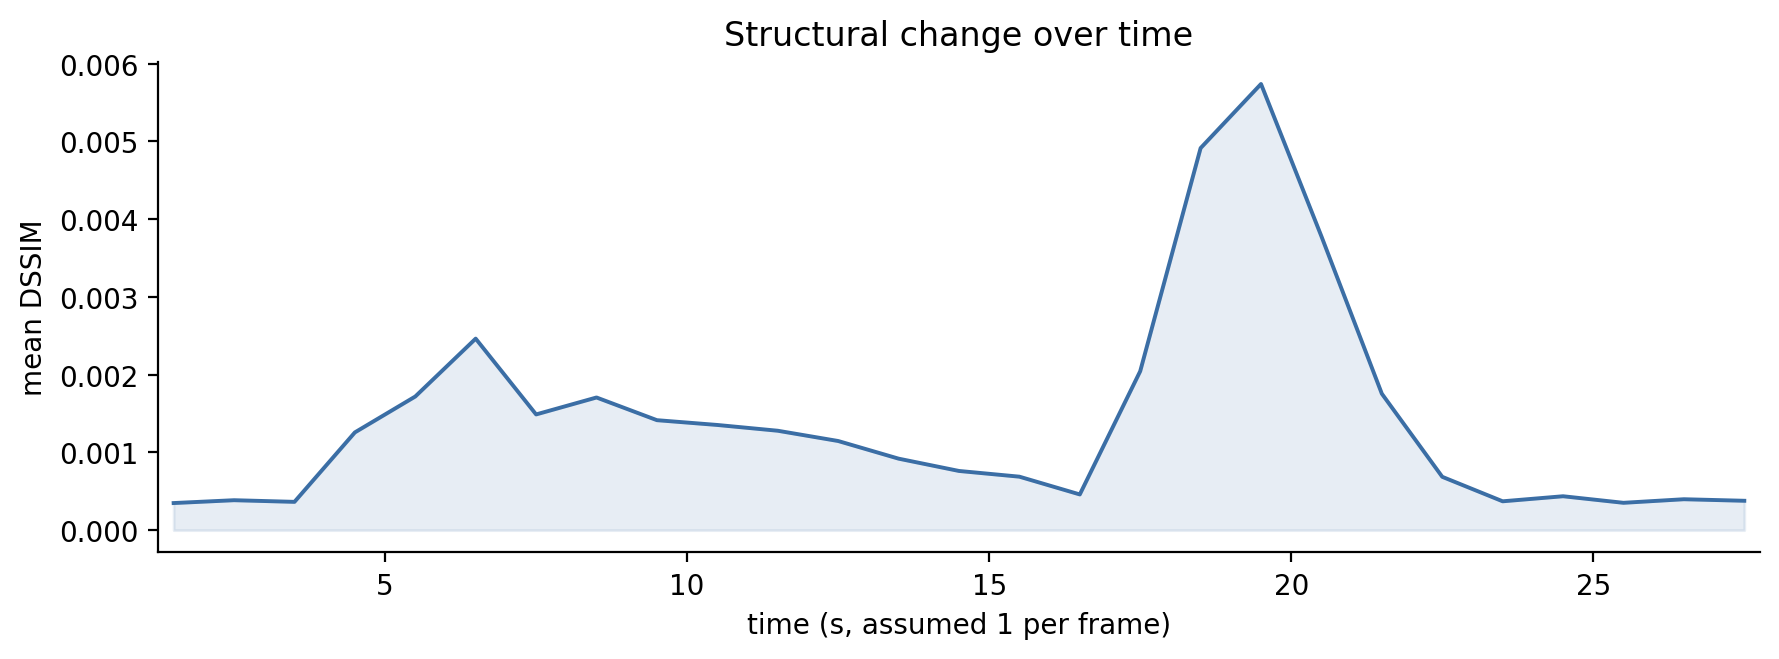

,dssim_frame_num,dssim_mean_value,data_frame_1_num,data_frame_2_num,data_frame_1_time,data_frame_2_time,dssim_frame_mean_time
0,0,0.000348,0,3,0.0,3.0,1.5
1,1,0.000385,1,4,1.0,4.0,2.5
2,2,0.000364,2,5,2.0,5.0,3.5
3,3,0.001257,3,6,3.0,6.0,4.5
4,4,0.001719,4,7,4.0,7.0,5.5


In [14]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(result.stats["dssim_frame_mean_time"], result.means, lw=1.4, color = "#3b6ea5")
ax.fill_between(result.stats["dssim_frame_mean_time"], result.means, alpha=0.12, color="#3b6ea5")
ax.set_xlabel("time" + ("" if TIMES else " (s, assumed 1 per frame)"))
ax.set_ylabel("mean DSSIM")
ax.set_title("Structural change over time")
ax.margins(x=0.01)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

result.stats.head()

## 6. Save the outputs

Writes four files into `OUTPUT_DIR`:

- `<RUN_NAME>_DSSIM_video.avi` — the colour-mapped DSSIM video
- `<RUN_NAME>_side_by_side.avi` — original data next to the DSSIM map
- `<RUN_NAME>_DSSIM_values.csv` — the per-frame table
- `<RUN_NAME>_DSSIM_run_info.csv` — every parameter used, so the run is reproducible

In [15]:
paths = dssim.save_results(
    result,
    run_name=RUN_NAME,
    output_dir=OUTPUT_DIR,
    data_frames=data,     # omit this to skip the side-by-side video
    fps=FPS,
)

print("\nSaved to", os.path.abspath(OUTPUT_DIR))

  wrote run1_DSSIM_video.avi
  wrote run1_DSSIM_values.csv
  wrote run1_DSSIM_run_info.csv
  wrote run1_side_by_side.avi

Saved to c:\Users\Han Solo\OneDrive - UC Irvine\Documents\SPYDER\DSSIM_Python\DSSIM_Analysis\DSSIM_Analysis_Python_Code\dssim_output


---

## Appendix — choosing your DSSIM parameters

### `GAUSS_BLUR_SIGMA` — denoising

DSSIM responds to *any* frame-to-frame difference, and is very sensitive to noise such as shot noise.
For noisy low-dose data, blurring first can help separate structural change from noise.
I typically start between 10-50 for 2048x2048 images and work backward as low as possible. This will depend heavily on structure feature size. Set it to 0 if the data has already been denoised (using ML denoising algorithms will typically perform much better than Gaussian denoising).

### `FRAME_OFFSET` — the time window

A value of `1` compares consecutive frames and captures fast changes. A value of 3 would compare frames 1,4 2,5 3,6 etc. Larger values look further apart in time, which raises sensitivity to slow drift but has poor temporal resolution for fast events. It also lowers the temporal resolution of the analysis (Nyquist limit). Again, I typically start with large values and work backward.

It costs nothing extra to compute; a larger offset simply yields fewer output frames.

### `RADIUS` — the neighborhood size

DSSIM compares a Gaussian-weighted neighborhood around every pixel. `RADIUS` is that neighborhood's standard
deviation, and the neighborhood spans `2 * ceil(3 * RADIUS) + 1` pixels per side.

Smaller neighborhoods give the highest spatial resolution and are the most sensitive to small structural
changes, but they are also the most likely to produce artifacts and 'false events' driven by noise. The
neighborhood should be smaller than the feature you care about — for nucleation events, smaller than the
particle. A practical recipe: start with a large frame offset *and* a large neighborhood to capture the most
obvious dynamics, then decrease both until the output becomes too noisy to interpret.

The outer `ceil(3 * RADIUS)` pixels of each frame are blanked, because the window there reaches past the edge of the image. Those blanked pixels are counted as zeros in `result.means`.

### `EXPONENTS` — which image properties are compared

**This is a lot of info but you generally only use (1,1,1) or (0,1,1).**

The metric compares Gaussian-weighted intensity values in a local neighborhood around each pixel
location using three components: the mean (*m*), variance (*v*), and normalized cross-correlation (*c*).
These components are weighted by the exponents [α β γ] and multiplied together to produce a SSIM
image, which is linearly converted to a DSSIM image:

$$\mathrm{SSIM}(X_t,\,X_{t+\Delta t}) \;=\; m(X_t,\,X_{t+\Delta t})^{\alpha}\;\;
v(X_t,\,X_{t+\Delta t})^{\beta}\;\; c(X_t,\,X_{t+\Delta t})^{\gamma}$$

$$\mathrm{DSSIM}(X_t,\,X_{t+\Delta t}) \;=\; \frac{1 - \mathrm{SSIM}(X_t,\,X_{t+\Delta t})}{2}$$

| Component | Coefficient | Compares |
|---|---|---|
| mean (*m*) | α | the weighted mean intensity of the local neighborhood |
| variance (*v*) | β | the weighted variance of intensity within the local neighborhood |
| cross-correlation (*c*) | γ | the weighted normalized cross-correlation between the two neighborhoods |

DSSIM values are between 0 and 1, where a high value corresponds to a region of high dissimilarity.

The coefficients should generally be kept at `(1, 1, 1)`. However, it can be useful to remove one
of the components by setting its coefficient to 0.

No exponent tuning was required for the LCTEM datasets in the publication. Whichever coefficients
you use are recorded in `<run_name>_DSSIM_run_info.csv`.

### Memory

The whole dataset is held in RAM as float32, so a run needs roughly:

```
frames x height x width x 4 bytes x 3
```

A 500-frame 2048x2048 dataset is about 25 GB. If you run out of memory, use `MAX_FRAMES`
to work in chunks, crop the frames before analysis, or bin them 2x2 first.

It is absolutely possible to optimize this algorithm with lazy loading to use basically zero RAM, but that's beyond the current scope of this work. It also makes tuning the parameters go way faster if you just keep the data in RAM. Also my workstation had 500 GB of DDR5 ECC RAM ¯\\___(ツ)___/¯. 

### Try a range of frame offsets

Optional. Shows how the measured change depends on the time window.

In [16]:
# offsets = [1, 2, 5, 10]
# fig, ax = plt.subplots(figsize=(9, 3.4))

# for off in offsets:
#     if off >= len(data_denoised):
#         continue
#     r = dssim.dssim_analysis(data_denoised, times=TIMES, frame_offset=off, radius=RADIUS,
#                              truncate_times=MAX_FRAMES is not None, verbose=False)
#     ax.plot(r.stats["dssim_frame_mean_time"], r.means, lw=1.3, label=f"offset {off}")

# ax.set_xlabel("time")
# ax.set_ylabel("mean DSSIM")
# ax.set_title("Effect of frame offset")
# ax.legend(frameon=False)
# ax.spines[["top", "right"]].set_visible(False)
# plt.tight_layout()
# plt.show()